# Chapter 3: Measurement

<a href="https://colab.research.google.com/github/choilab-jefferson/medimage/blob/main/Chapter03_Measurement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 2 ended with a selection: a set of pixels marked as fat, or as muscle. A selection is not
yet a measurement. This chapter turns it into numbers — areas, volumes, averages — and then asks
the question that matters more than any of them: **is the number right?**

By the end you will be able to:

1. Split a selection into separate objects and pick out the one you want.
2. Convert pixel counts into square centimeters and millilitres.
3. Summarize the values inside a region — the average is itself a clinical measurement.
4. Locate a region: its center, and how deep inside it a point is.
5. Compare your result against a reference using **Dice**, and read what the number is telling you.

The last point is the important one. Any code will produce a number. Only a comparison tells you
whether to believe it.

### Before you start

| | |
|---|---|
| **Builds on** | Chapter 1 (loading, spacing) and Chapter 2 (masks, smoothing, `body_mask`) |
| **Downloads** | The Chapter 1 Pancreas-CT subject (~40 MB), plus one CHAOS MRI subject (~9 MB) for Part B |
| **Longest wait** | The CHAOS download. It is fetched from Zenodo one file at a time, so give it a minute |
| **Beyond the setup cell** | Nothing extra to install |
| **Hardware** | Any laptop. No GPU needed |

The chapter comes in two halves. **Part A** measures on CT and is a direct continuation of
Chapter 2. **Part B** switches to MRI to answer a different question — not *what is the number* but
*is the number right* — because the MRI dataset comes with expert reference outlines to check
against, and the CT does not.

## Setup

In [1]:
# --- Setup: Google Colab (primary) and local checkout (testing) ---------------
REPO_URL = "https://github.com/choilab-jefferson/medimage.git"
REPO_DIR = "medimage"

import os
import pathlib
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    # On Colab the repository is not present yet, so clone it and install the
    # few packages that are not part of the default runtime.
    if not pathlib.Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pydicom", "remotezip"],
        check=True,
    )
else:
    # Locally the notebook already lives inside the repository; walk up until
    # we find the module that the notebooks import.
    root = pathlib.Path.cwd().resolve()
    while not (root / "medimage_data.py").is_file() and root != root.parent:
        root = root.parent
    os.chdir(root)

print("Running on Colab:", IN_COLAB)
print("Working directory:", pathlib.Path.cwd().name)

Running on Colab: False
Working directory: medimage


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi

import medimage_data as md

vol, spacing, datasets = md.load_series(md.fetch_pancreas_ct(0))
dz, dy, dx = spacing

sl = vol[len(vol) // 2].astype(np.float32)

px_area_cm2 = dy * dx / 100              # area of one pixel
voxel_mL = dz * dy * dx / 1000           # volume of one voxel (1 mL = 1000 mm^3)

print(f"one pixel  = {px_area_cm2:.5f} cm^2")
print(f"one voxel  = {voxel_mL:.5f} mL")

PANCREAS_0076: 210 slices in data/pancreas-ct/PANCREAS_0076
Source: Roth H, Farag A, Turkbey EB, Lu L, Liu J, Summers RM (2016). Data From Pancreas-CT. The Cancer Imaging Archive. https://doi.org/10.7937/K9/TCIA.2016.tNB1kqBU  (CC BY 3.0)


one pixel  = 0.00807 cm^2
one voxel  = 0.00081 mL


## Part A — Measuring on CT

### 1. From one selection to separate objects

A mask says "these pixels are muscle". It does not say *which* muscle. Two regions that never touch
are still one mask as far as NumPy is concerned.

`ndi.label` fixes that. It walks the mask and gives every group of touching pixels its own number:
background stays 0, the first object becomes 1, the next 2, and so on. This is called finding
**connected components**.

In [3]:
# Reuse the pipeline from Chapter 2: smooth, find the body, then threshold.
def body_mask(slice_hu, threshold=-500):
    mask = ndi.binary_fill_holes(slice_hu > threshold)
    labels, n = ndi.label(mask)
    if n == 0:
        return mask
    sizes = ndi.sum_labels(np.ones_like(labels), labels, range(1, n + 1))
    return labels == int(np.argmax(sizes)) + 1


smooth = ndi.gaussian_filter(sl, 2)
body = body_mask(sl)

muscle = body & (smooth >= -29) & (smooth < 150)
muscle = ndi.binary_opening(muscle, np.ones((3, 3)))

labels, n_objects = ndi.label(muscle)
print(f"the mask contains {n_objects} separate objects")

the mask contains 21 separate objects


### 2. Picking the object you want

Most of those objects are tiny fragments. Real anatomy is large, so sorting by size and keeping the
big ones removes most of the noise in one step.

`ndi.sum_labels` is the tool: give it a value per pixel and a label image, and it totals the values
inside each labeled object. Feeding it an array of ones totals the *pixels*, which is the area.

In [4]:
sizes = ndi.sum_labels(np.ones_like(labels), labels, range(1, n_objects + 1))
order = np.argsort(sizes)[::-1]

print("the ten largest objects:")
for rank, idx in enumerate(order[:10], start=1):
    print(f"  {rank:2d}. label {idx + 1:4d}   {int(sizes[idx]):6d} px   "
          f"{sizes[idx] * px_area_cm2:7.1f} cm^2")

print(f"\n{np.count_nonzero(sizes < 20)} of {n_objects} objects are smaller than 20 px")

the ten largest objects:
   1. label    1    51887 px     418.8 cm^2
   2. label    6      213 px       1.7 cm^2
   3. label   11      194 px       1.6 cm^2
   4. label    4      185 px       1.5 cm^2
   5. label   20      141 px       1.1 cm^2
   6. label   13      133 px       1.1 cm^2
   7. label    9      125 px       1.0 cm^2
   8. label    7      117 px       0.9 cm^2
   9. label   15      117 px       0.9 cm^2
  10. label   16      107 px       0.9 cm^2

2 of 21 objects are smaller than 20 px


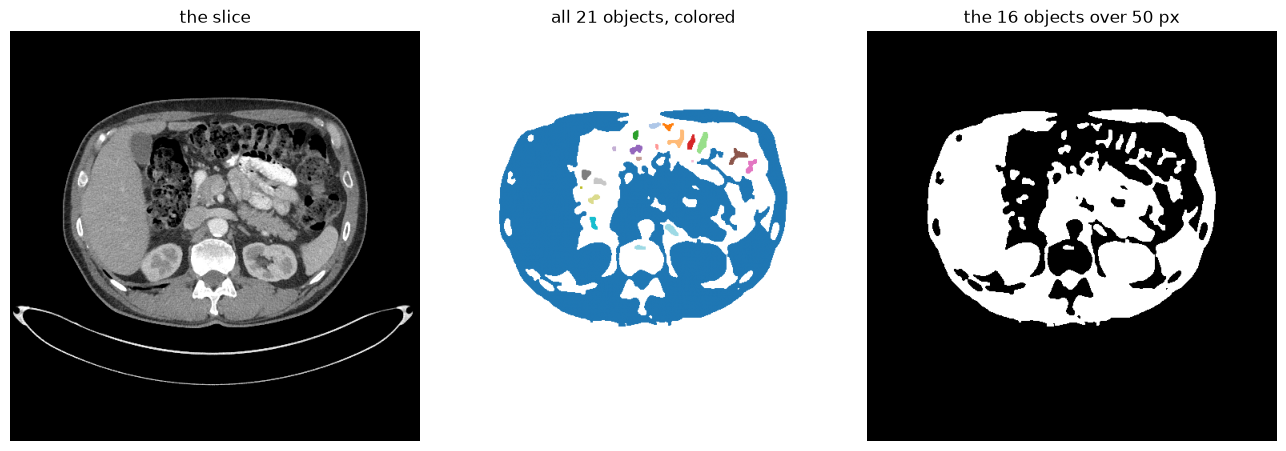

In [5]:
keep = [idx + 1 for idx in order if sizes[idx] >= 50]
big_objects = np.isin(labels, keep)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
axes[0].imshow(sl, cmap="gray", vmin=-160, vmax=240)
axes[0].set_title("the slice")
axes[1].imshow(np.where(labels > 0, labels, np.nan), cmap="tab20")
axes[1].set_title(f"all {n_objects} objects, colored")
axes[2].imshow(big_objects, cmap="gray")
axes[2].set_title(f"the {len(keep)} objects over 50 px")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 3. Areas and volumes

This is the whole trick, and it is worth stating plainly because everything in Chapter 6 rests
on it:

> **area = number of pixels × area of one pixel**
>
> **volume = number of voxels × volume of one voxel**

The pixel count comes from the mask. The pixel size comes from the header. Neither is useful
without the other.

In [6]:
fat = ndi.binary_opening(body & (smooth >= -190) & (smooth < -30), np.ones((3, 3)))

print("on this single slice")
print(f"  fat            {fat.sum():7d} px  ->  {fat.sum() * px_area_cm2:7.1f} cm^2")
print(f"  muscle+organs  {muscle.sum():7d} px  ->  {muscle.sum() * px_area_cm2:7.1f} cm^2")

# The same idea in 3D, over the whole scan.
smooth3d = ndi.gaussian_filter(vol.astype(np.float32), (0, 2, 2))
body3d = np.stack([body_mask(v) for v in vol])
fat3d = body3d & (smooth3d >= -190) & (smooth3d < -30)

print(f"\nover the whole scan ({vol.shape[0]} slices)")
print(f"  total fat      {fat3d.sum():7d} voxels  ->  {fat3d.sum() * voxel_mL:7.0f} mL")

on this single slice
  fat              28431 px  ->    229.5 cm^2
  muscle+organs    53820 px  ->    434.4 cm^2



over the whole scan (210 slices)
  total fat      5298798 voxels  ->     4277 mL


### 4. What is inside a region

Counting pixels tells you how much. Averaging their values tells you what kind — and on CT, where
the values are calibrated, that average is a clinical measurement in its own right.

Muscle that is infiltrated with fat has a *lower* average HU than healthy muscle. That drop has a
name, **myosteatosis**, and it predicts poor outcomes independently of how much muscle there is. So
"how much" and "what quality" are two different numbers, and you want both.

In [7]:
muscle_values = sl[muscle]

print("muscle region")
print(f"  pixels           {muscle_values.size}")
print(f"  mean             {muscle_values.mean():7.1f} HU   <- the quality measure")
print(f"  standard dev     {muscle_values.std():7.1f} HU")
print(f"  median           {np.median(muscle_values):7.1f} HU")

# Per-object statistics come straight from ndi, without looping.
means = ndi.mean(sl, labels, index=keep[:5])
print("\nmean HU of the five largest objects:")
for lab, m in zip(keep[:5], means):
    print(f"  label {lab:4d}   {m:7.1f} HU")

muscle region
  pixels           53820
  mean                54.0 HU   <- the quality measure
  standard dev        48.7 HU
  median              58.0 HU

mean HU of the five largest objects:
  label    1      55.3 HU
  label    6      15.2 HU
  label   11       4.0 HU
  label    4      30.9 HU
  label   20      10.1 HU


### 5. Where a region is

Two more measurements that come up constantly.

**Center of mass** is the average position of a region — useful for tracking something across
slices, or checking that an object is where you expect.

**Distance transform** replaces every pixel inside a mask with its distance to the nearest edge. It
answers "how deep inside am I", which is how you find the core of a structure, or peel off a rim.

center of mass: row 239.9, column 243.3
deepest point is 38.2 mm from the edge


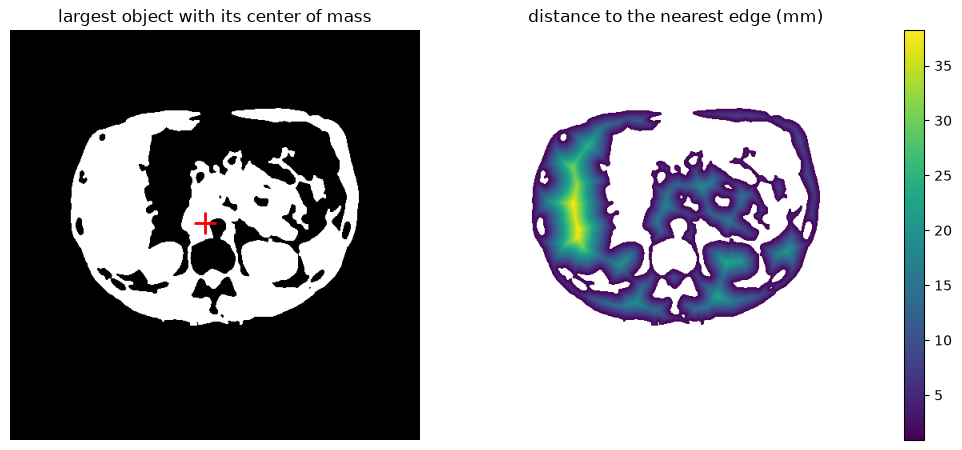

In [8]:
biggest = labels == keep[0]

cy, cx = ndi.center_of_mass(biggest)
depth = ndi.distance_transform_edt(biggest, sampling=(dy, dx))

print(f"center of mass: row {cy:.1f}, column {cx:.1f}")
print(f"deepest point is {depth.max():.1f} mm from the edge")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
axes[0].imshow(biggest, cmap="gray")
axes[0].plot(cx, cy, "r+", markersize=16, markeredgewidth=2)
axes[0].set_title("largest object with its center of mass")
im = axes[1].imshow(np.where(biggest, depth, np.nan), cmap="viridis")
axes[1].set_title("distance to the nearest edge (mm)")
plt.colorbar(im, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Part B — Is the number right?

Everything so far produces numbers happily. None of it tells you whether they are correct.

To find out you need a **reference**: the same structure outlined by someone who knows what they
are looking at. We now switch to an MRI dataset that comes with exactly that — CHAOS, in which
radiologists outlined the liver, both kidneys and the spleen on every slice.

In [9]:
in_phase, out_phase, reference, mr_spacing = md.load_chaos(1)
mz, my, mx = mr_spacing
mr_voxel_mL = mz * my * mx / 1000

print("MRI volume:", in_phase.shape)
print(f"voxel size: {mz:.1f} x {my:.2f} x {mx:.2f} mm  ->  {mr_voxel_mL:.4f} mL")
print("\nstructures outlined by the radiologists:")
for value, name in md.CHAOS_LABELS.items():
    n_vox = np.count_nonzero(reference == value)
    print(f"  {name:14s} {n_vox * mr_voxel_mL:7.0f} mL")

MRI volume: (35, 256, 256)
voxel size: 5.5 x 1.89 x 1.89 mm  ->  0.0197 mL

structures outlined by the radiologists:
  liver             1489 mL
  right kidney       199 mL
  left kidney        204 mL
  spleen             121 mL


Those volumes are worth a sanity check against what a body actually contains: an adult liver is
around 1200–1600 mL, each kidney around 150 mL, the spleen 100–200 mL. The numbers land where they
should, which is a good sign that the masks are paired with the right slices.

That pairing is a genuine trap, by the way. The reference masks are stored as image files in
scanning order, while the scan itself gets sorted head first. Line them up by position and every
slice is matched to the wrong outline — and the result still looks superficially reasonable. The
loader pairs them by file name instead, because each mask file shares its name with the slice it
belongs to.

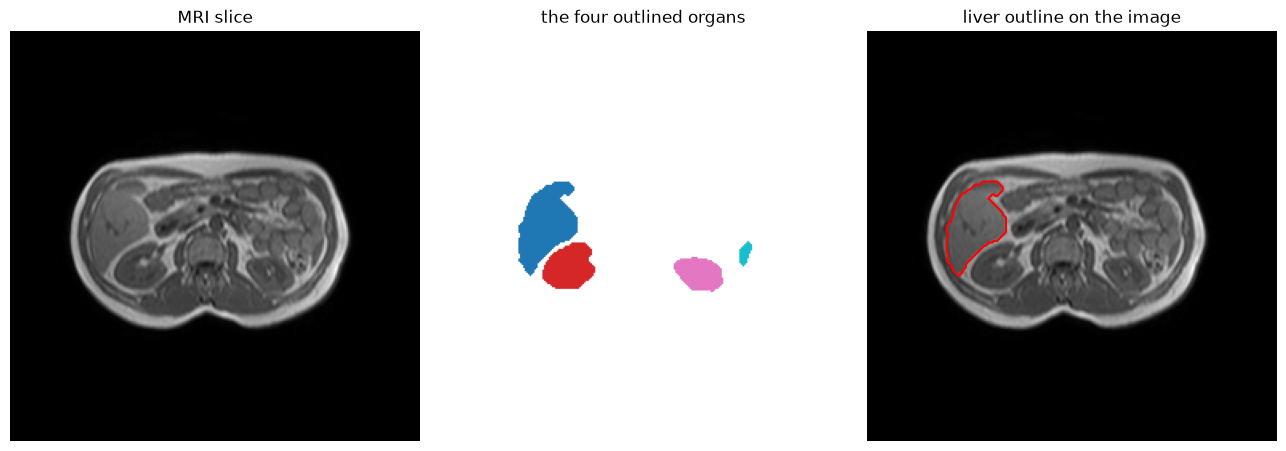

In [10]:
liver = reference == 63
mid = in_phase.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
axes[0].imshow(in_phase[mid], cmap="gray")
axes[0].set_title("MRI slice")
axes[1].imshow(np.where(reference[mid] > 0, reference[mid], np.nan), cmap="tab10")
axes[1].set_title("the four outlined organs")
axes[2].imshow(in_phase[mid], cmap="gray")
axes[2].contour(liver[mid], colors="red", linewidths=1.5)
axes[2].set_title("liver outline on the image")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Now try to find the liver ourselves

We will use the method from Chapter 2 — pick an intensity range, keep the biggest blob — and see
how close it gets. The liver sits on the patient's right, which appears on the **left** of the
image, so we also restrict the search to that half.

In [11]:
smooth_mr = ndi.gaussian_filter(in_phase.astype(np.float32), 1.0)
mr_body = ndi.binary_fill_holes(smooth_mr > 40)

guess = mr_body & (smooth_mr >= 300) & (smooth_mr <= 650)
guess[:, :, in_phase.shape[2] // 2:] = False          # keep the patient's right side
guess = ndi.binary_opening(guess, np.ones((1, 3, 3)))

lab, n = ndi.label(guess)
sizes = ndi.sum_labels(np.ones_like(lab), lab, range(1, n + 1))
guess = lab == int(np.argmax(sizes)) + 1
guess = ndi.binary_fill_holes(ndi.binary_closing(guess, np.ones((1, 5, 5))))

print(f"our estimate  {guess.sum() * mr_voxel_mL:7.0f} mL")
print(f"reference     {liver.sum() * mr_voxel_mL:7.0f} mL")

our estimate     4761 mL
reference        1489 mL


### Dice: how much two shapes agree

Comparing volumes is not enough. Two shapes can have identical volumes and sit in completely
different places.

**Dice** compares the shapes themselves. Count the pixels the two masks share, double it, and
divide by the total number of pixels in both:

$$\text{Dice} = \frac{2 \times (\text{pixels in both})}{(\text{pixels in A}) + (\text{pixels in B})}$$

It runs from 0 (no overlap at all) to 1 (identical). As a rough guide, above 0.9 is excellent,
0.7–0.9 is usable for many purposes, and below 0.5 means the result is not measuring the structure
you named it after.

In [12]:
def dice(a, b):
    """Overlap between two boolean masks, from 0 (none) to 1 (identical)."""
    shared = np.count_nonzero(a & b)
    return 2 * shared / (np.count_nonzero(a) + np.count_nonzero(b))


score = dice(guess, liver)
volume_error = guess.sum() / liver.sum()

print(f"Dice          {score:.3f}")
print(f"volume ratio  {volume_error:.1f}x too large")

Dice          0.448
volume ratio  3.2x too large


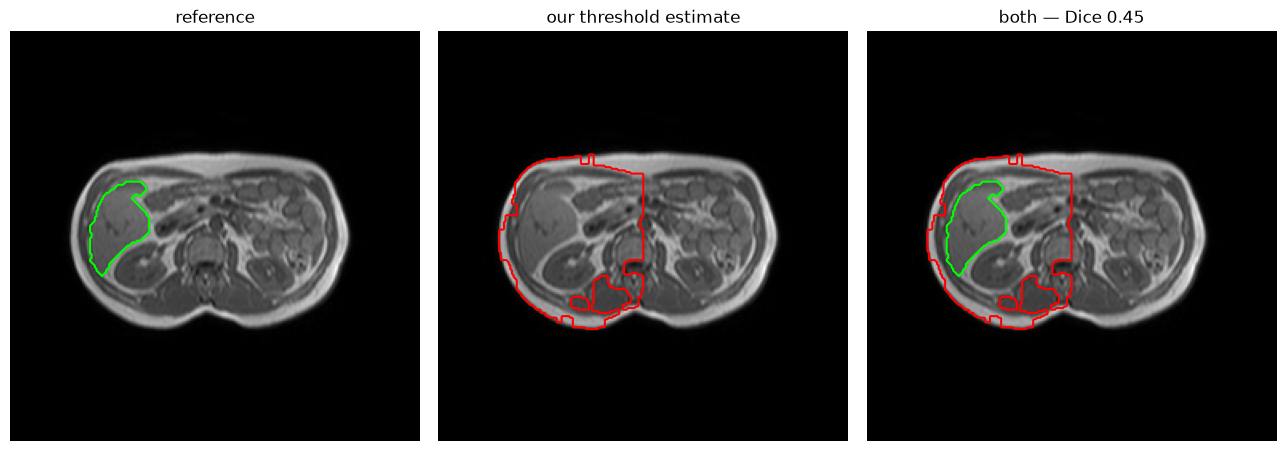

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
axes[0].imshow(in_phase[mid], cmap="gray")
axes[0].contour(liver[mid], colors="lime", linewidths=1.5)
axes[0].set_title("reference")
axes[1].imshow(in_phase[mid], cmap="gray")
axes[1].contour(guess[mid], colors="red", linewidths=1.5)
axes[1].set_title("our threshold estimate")
axes[2].imshow(in_phase[mid], cmap="gray")
axes[2].contour(liver[mid], colors="lime", linewidths=1.5)
axes[2].contour(guess[mid], colors="red", linewidths=1.5)
axes[2].set_title(f"both — Dice {score:.2f}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### What that number is telling us

The estimate spills far beyond the liver, and Dice says so. Without the reference we would have
reported a liver volume several times too large and had no way of knowing.

The reason is the same one Chapter 2 ended on, but worse here. On CT, thresholds work because
Hounsfield units are anchored to fixed physical points — water is always 0, air is always −1000.

**MRI has no such anchor.** Its brightness depends on the sequence, the scanner, the coil and where
the tissue sits relative to it. A value of 400 means nothing on its own, and a threshold tuned on
one scan does not transfer to the next. That is why segmenting MRI essentially always relies on
learned models or reference outlines rather than fixed cut-offs.

It is also why Chapter 7, which measures body fat on MRI, does not threshold at all. Instead it
combines two images physically to compute a **fat fraction** — a real proportion, not a brightness —
which restores the calibrated quantity that MRI otherwise lacks.

## Recap

**Part A — turning a selection into numbers.**

| | |
|---|---|
| **Separate objects** | `ndi.label` numbers each connected blob |
| **Pick the ones you want** | `ndi.sum_labels` over an array of ones totals the pixels per object, so sorting by size and dropping the fragments is one step. "Keep the large ones" is a rule you should state rather than assume |
| **Area** | pixels × `dy * dx`, divided by 100 for cm² |
| **Volume** | voxels × `dz * dy * dx`, divided by 1000 for millilitres |
| **What is inside** | Mean, median and standard deviation of the HU *inside* the mask. Mean muscle HU is itself a clinical measurement — fat infiltrating muscle lowers it |
| **Where it is** | `ndi.center_of_mass`, and `ndi.distance_transform_edt` for how deep inside a point sits |

**Part B — checking it.** Dice is `2 × overlap / (size A + size B)`: 1.0 is identical, 0.0 is no
overlap at all. The threshold estimate of the liver scored badly, and the reason generalizes:

- **A calibrated scale is what makes a fixed threshold portable.** CT has one, so −190 to −30 HU
  means fat in any hospital. MRI does not, so a brightness cut-off tuned on one scan is worth
  nothing on the next.
- **Volume agreement is a weaker check than Dice.** Two shapes can have the same volume in
  completely different places. Exercise 2 makes this concrete.
- **Without a reference you would not have known.** The wrong answer arrived with no warning
  attached, which is the recurring theme of the whole course.

**Next:** Chapter 4 handles the problem that appears as soon as you have two of these measurements —
two scans are on different grids, of differently sized people, and cannot be compared as they stand.

## Exercises

1. Compute Dice for the spleen (label 252) using the same threshold approach. Is it better or worse
   than the liver, and can you explain why from the images?

   *Hint:* swap the label value in the reference comparison and keep everything else the same. The
   spleen is smaller, so think about what a fixed amount of boundary error does to Dice for a small
   object versus a large one.

2. The threshold estimate is too large. Try shrinking it with `ndi.binary_erosion` until the volume
   matches the reference. Does Dice improve as much as the volume error does? What does that tell
   you about using volume agreement as a check?

   *Hint:* loop `ndi.binary_erosion(mask, iterations=k)` over `k`, printing volume error and Dice
   side by side. Expect volume error to reach nearly zero while Dice stays poor — the shape is in
   the wrong place, and matching totals cannot fix that.

3. Measure fat area on ten consecutive CT slices and plot it. How much does the answer depend on
   which slice you pick? (Chapter 6 has to solve exactly this.)

   *Hint:* this repeats Chapter 2's exercise 3 deliberately. Now that you can convert to cm², state
   the spread as a real area rather than a pixel count.

4. Calculate the mean HU of muscle on the first and last slice of the CT. If they differ, is that
   real myosteatosis or an artifact of which anatomy each slice contains?

   *Hint:* `vol[0]` and `vol[-1]` are tens of centimeters apart in the body, so they contain
   different muscles entirely. To ask the clinical question properly you would need the *same*
   muscle in both — which is why Chapter 6 measures at one standardized anatomical level.

## References

- [scipy.ndimage documentation](https://docs.scipy.org/doc/scipy/reference/ndimage.html)
- Dice LR. *Measures of the amount of ecologic association between species.* Ecology.
  1945;26(3):297–302.
- Kavur AE, Gezer NS, Barış M, et al. *CHAOS Challenge — combined (CT-MR) healthy abdominal organ
  segmentation.* Medical Image Analysis. 2021;69:101950.
  [doi:10.1016/j.media.2020.101950](https://doi.org/10.1016/j.media.2020.101950)
- Roth H, et al. (2016). *Data From Pancreas-CT.* The Cancer Imaging Archive.
  [doi:10.7937/K9/TCIA.2016.tNB1kqBU](https://doi.org/10.7937/K9/TCIA.2016.tNB1kqBU)